# <br><center>**Statistical Bootstrapping – Penguins**

In [1]:
import gc; gc.enable()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.figsize": (14,8),
    "font.size": 14,
    "axes.grid": True,
    "grid.alpha": 0.2
})
import seaborn as sns

import scipy.stats as stats
from tqdm.notebook import tqdm

print("setup done!")

setup done!


In [2]:
# load data
df = sns.load_dataset("penguins").dropna()

print(f"shape: {df.shape}")
df.head()

shape: (333, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [3]:
# how much bigger are male penguins than female penguins
def delta_mass(df):
    return df.query("sex == 'Male'").body_mass_g.mean() \
        - df.query("sex == 'Female'").body_mass_g.mean()

delta = delta_mass(df)
print(f"Difference: {delta:.2f}g")

Difference: 683.41g


## <center>**What now?**
<div style="display: flex; justify-content: center; font-size: 1rem">
If this was the quantity we were interested in, we could report this alone. <br><br>
Instead, we are going to use bootstrapping to create a 95% confidence interval!
</div>

In [4]:
n = df.shape[0]

for boot in range(5):
    df_boot = df.sample(n, replace=True)
    delta_boot = delta_mass(df_boot)
    print(f"Boot {boot+1}: Difference = {delta_mass(df_boot):.2f}g")

Boot 1: Difference = 617.22g
Boot 2: Difference = 661.71g
Boot 3: Difference = 829.29g
Boot 4: Difference = 665.41g
Boot 5: Difference = 646.94g


<div style="display: flex; justify-content: center; font-size: 1rem">
Treat these as random variables X1 , . . . , Xm for m bootstraps
</div>

bootstrapping statistic:   0%|          | 0/1000 [00:00<?, ?it/s]

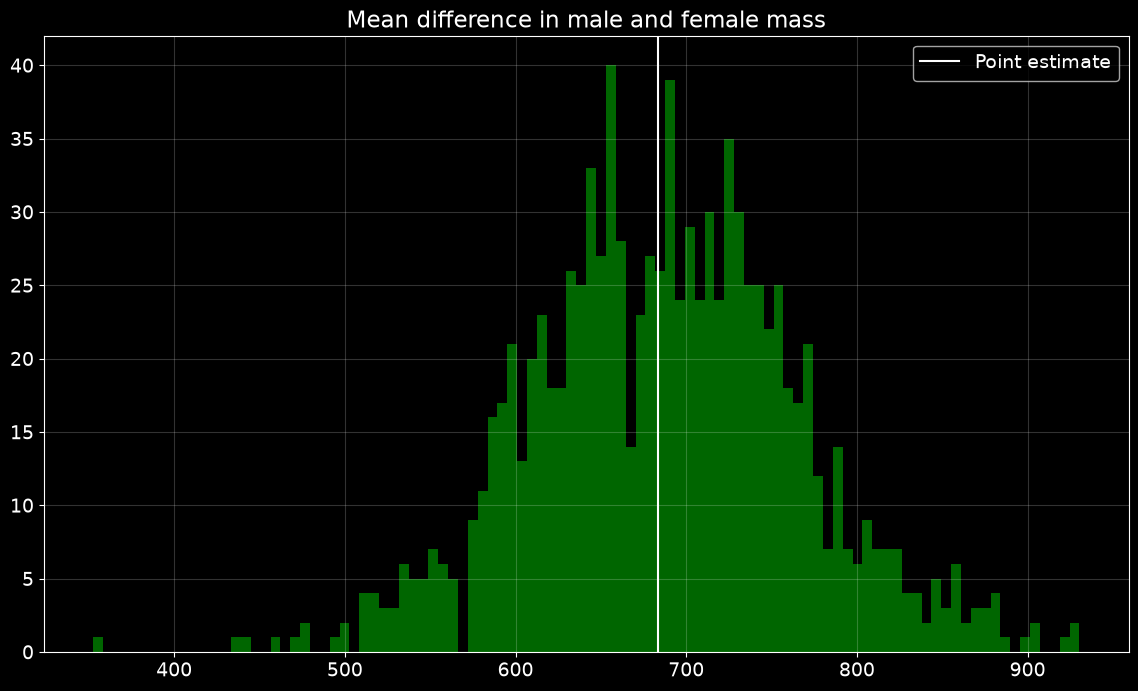

In [5]:
m = 1000
boot_statistics = np.zeros(m)

for boot in tqdm(range(m), desc="bootstrapping statistic", leave=False):
    df_boot = df.sample(n, replace=True, random_state=67*(boot+41))
    boot_statistics[boot] = delta_mass(df_boot)

plt.hist(boot_statistics, bins=100, color="green", alpha=0.8)
plt.axvline(delta, label="Point estimate")
plt.title("Mean difference in male and female mass")
plt.legend(); plt.show()

In [6]:
# confidence interval
theta_mean = np.mean(boot_statistics)
theta_std = np.std(boot_statistics)

z_coeff = 2.33 # 98% confidence interval
error_margin = z_coeff * theta_std / np.sqrt(m)

theta_lower = theta_mean - error_margin
theta_upper = theta_mean + error_margin

print(f"98% CI: [{theta_lower:.4f}, {theta_upper:.4f}]")

98% CI: [681.8286, 693.4688]


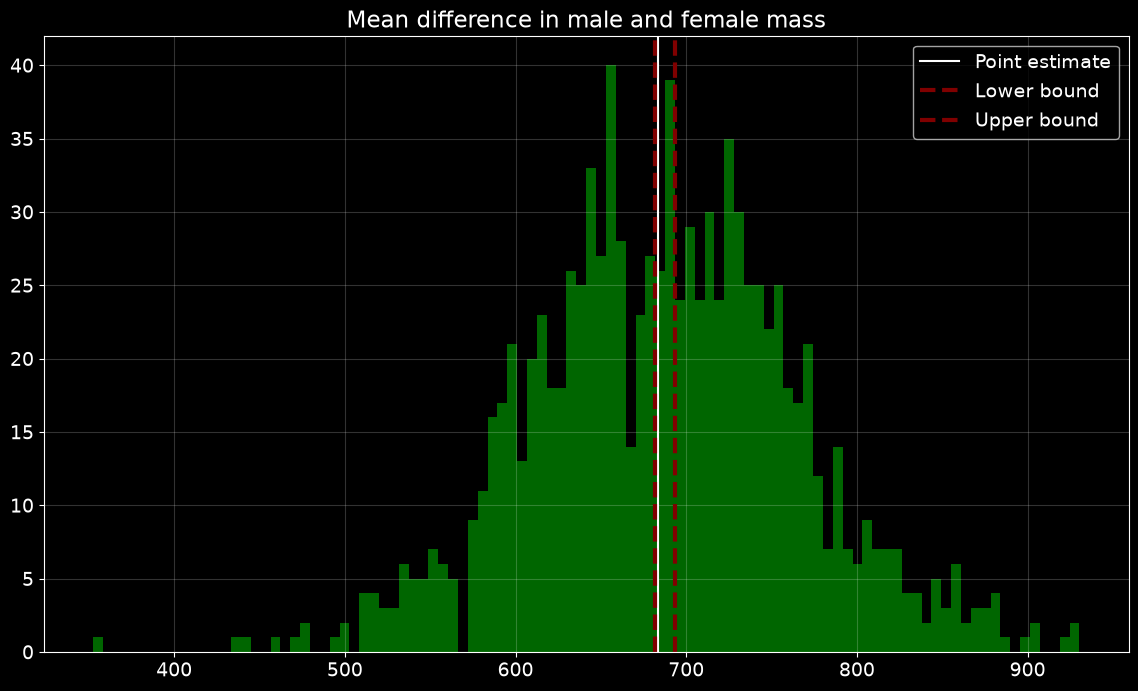

In [7]:
plt.hist(boot_statistics, bins=100, color="green", alpha=0.8)
plt.axvline(delta, label="Point estimate")
plt.axvline(theta_lower, linestyle="--", linewidth=3, color="maroon", label="Lower bound")
plt.axvline(theta_upper, linestyle="--", linewidth=3, color="maroon", label="Upper bound")
plt.title("Mean difference in male and female mass")
plt.legend(); plt.show()

bootstrapping statistic:   0%|          | 0/10000 [00:00<?, ?it/s]

98% CI: [682.1236, 685.8688]


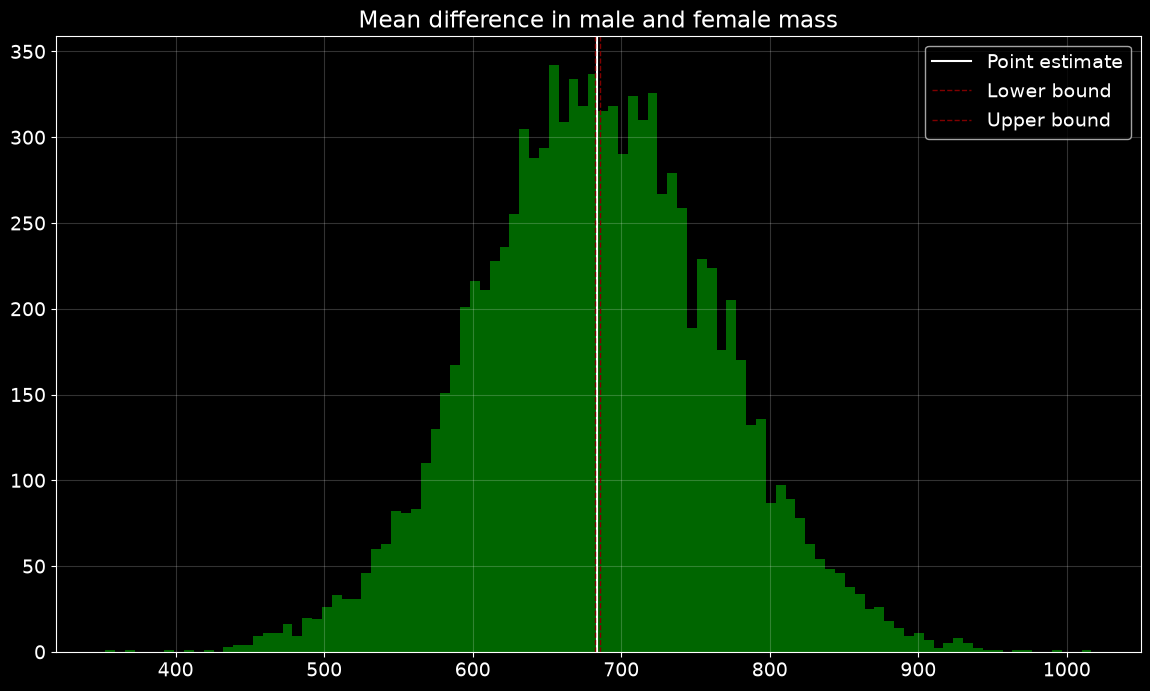

In [8]:
# 10.000 bootstraps
m = 10_000
boot_statistics = np.zeros(m)

for boot in tqdm(range(m), desc="bootstrapping statistic", leave=False):
    df_boot = df.sample(n, replace=True, random_state=67*(boot+41))
    boot_statistics[boot] = delta_mass(df_boot)

theta_mean = np.mean(boot_statistics)
theta_std = np.std(boot_statistics)

z_coeff = 2.33 # 98% confidence interval
error_margin = z_coeff * theta_std / np.sqrt(m)

theta_lower = theta_mean - error_margin
theta_upper = theta_mean + error_margin

print(f"98% CI: [{theta_lower:.4f}, {theta_upper:.4f}]")

plt.hist(boot_statistics, bins=100, color="green", alpha=0.8)
plt.axvline(delta, label="Point estimate")
plt.axvline(theta_lower, linestyle="--", linewidth=1, color="maroon", label="Lower bound")
plt.axvline(theta_upper, linestyle="--", linewidth=1, color="maroon", label="Upper bound")
plt.title("Mean difference in male and female mass")
plt.legend(); plt.show()